# 03: Cluster-Randomized Estimators for Direct and Spillover Effects

This notebook is the first causal estimation notebook in the interference and spillover workflow.

The previous notebook created a randomized promotion simulation from MovieLens seed slates. In each slate, one lower-ranked focal movie was selected, and the slate was randomized to either promote that focal movie or leave the slate unchanged. That gives us a clean assignment mechanism:

- the **randomized unit** is the slate,
- the **directly treated unit** is the promoted focal movie,
- the **spillover-exposed units** are the other movies in a promoted slate,
- the strongest spillover candidates are movies in the same genre-based substitute cluster as the promoted focal movie,
- the **total effect** is measured at the slate level because gains and losses happen inside the same attention budget.

The goal here is to estimate what changed when promotion was randomized:

1. **Direct focal effect**: what happens to the promoted movie?
2. **Same-cluster spillover effect**: what happens to substitute movies in the same slate?
3. **Displaced-item spillover effect**: what happens to items that are pushed down by promotion?
4. **Total slate effect**: what happens to total slate engagement after combining gains and losses?

Because treatment is assigned at the slate level, uncertainty should respect slate clustering. The notebook therefore compares naive standard errors with slate-clustered standard errors and also uses a cluster bootstrap as a non-parametric check.


<!-- dataset-experiment-context -->
## Dataset and Simulation Design Context

This project uses MovieLens 32M as a realistic user-item preference source. MovieLens contains ratings and movie metadata, but it lacks production recommendation impressions, randomized promotions, and observed slate outcomes.

Because the public data lack a real experiment, the project builds a transparent simulation. It constructs recommendation slates, selects lower-ranked focal movies, randomizes focal promotion at the slate level, and generates outcomes through an explicit competition model.

The simulated experiment is designed to teach interference. Promoting one item can increase that item's engagement while reducing attention for substitutes and neighboring items. The estimands are direct focal effects, spillover effects, and total slate value, so the project emphasizes experiment design and measurement logic as a teaching workflow.

**Role of this notebook.** This notebook estimates direct and slate-level effects under the simulated randomized assignment and compares estimates with known simulation truth.

<!-- mathematical-setup -->

## Mathematical Setup

Cluster randomization assigns treatment at the group level to reduce spillover contamination. For cluster \(c\), let \(Z_c\) be the randomized assignment and \(\bar Y_c\) the cluster mean outcome. A simple cluster-level difference in means is

$$
\widehat\tau=\frac{1}{n_1}\sum_{c:Z_c=1}\bar Y_c-
\frac{1}{n_0}\sum_{c:Z_c=0}\bar Y_c.
$$

A cluster-bootstrap uncertainty calculation resamples clusters:

$$
\widehat{\operatorname{SE}}_{\text{cluster}}(\widehat\tau)
=\operatorname{sd}\left(\widehat\tau^{*(1)},\ldots,\widehat\tau^{*(B)}\right).
$$

Because items inside a cluster are related, uncertainty should respect the assignment level. That is why this notebook compares naive uncertainty with cluster-robust or cluster-bootstrap uncertainty.


#### 1. Environment and Paths

This cell imports the estimation, plotting, and table tools used in the notebook. It also finds the repository root by searching upward for the exposure mapping file, which keeps the notebook robust across Jupyter and command-line execution.


In [1]:
# Set up environment and paths.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_DIR = next(
    root for root in candidate_roots
    if (root / "data" / "processed" / "movielens_interference_exposure_mapping.parquet").exists()
)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "interference_spillover_effects"

EXPOSURE_PATH = PROCESSED_DIR / "movielens_interference_exposure_mapping.parquet"
SLATE_OUTCOME_PATH = PROCESSED_DIR / "movielens_interference_slate_outcomes.parquet"
ASSIGNMENT_PATH = PROCESSED_DIR / "movielens_interference_assignment_table.parquet"

EXPOSURE_PATH.exists(), SLATE_OUTCOME_PATH.exists(), ASSIGNMENT_PATH.exists()


(True, True, True)

All three checks should be `True`. The notebook depends on the item-row exposure table, the slate-level outcome table, and the focal assignment table produced in the previous notebook.


#### 2. Load the Randomized Exposure Data

This cell loads the analysis-ready data. The item-row table is used for direct and spillover contrasts, while the slate-level table is used for total-effect estimates. The assignment table is useful for checking that the randomized design is still intact.


In [2]:
exposure = pd.read_parquet(EXPOSURE_PATH)
slate_outcomes = pd.read_parquet(SLATE_OUTCOME_PATH)
assignment = pd.read_parquet(ASSIGNMENT_PATH)

load_summary = pd.DataFrame(
    {
        "table": ["item_row_exposure", "slate_outcomes", "assignment"],
        "rows": [len(exposure), len(slate_outcomes), len(assignment)],
        "unique_slates": [
            exposure["slate_id"].nunique(),
            slate_outcomes["slate_id"].nunique(),
            assignment["slate_id"].nunique(),
        ],
        "unique_users": [
            exposure["userId"].nunique(),
            slate_outcomes["userId"].nunique(),
            assignment["userId"].nunique(),
        ],
    }
)

display(load_summary)
display(exposure.head())


,table,rows,unique_slates,unique_users
0,item_row_exposure,36000,3000,3000
1,slate_outcomes,3000,3000,3000
2,assignment,3000,3000,3000


,slate_id,userId,movieId,title,genres,primary_genre,spillover_cluster,slate_position_seed,observed_relevance,high_relevance,rating_datetime,rating_year,sample_rating_count,sample_mean_rating,sample_liked_rate,popularity_bucket,n_ratings,mean_rating,liked_rate,active_years,unique_primary_genres,activity_span_days,focal_movieId,focal_title,focal_spillover_cluster,focal_seed_position,promotion_probability,promotion_applied,assignment_arm,is_focal_item,direct_treatment,same_slate_spillover,same_cluster_spillover,displaced_by_promotion,final_position,baseline_visibility,final_visibility,visibility_gain,position_change,exposure_group,log_item_popularity,log_item_popularity_z,p_no_promotion,p_observed,known_probability_lift,simulated_click,simulated_engagement_score
0,user_50_seed,50,4027,"O Brother, Where Art Thou? (2000)",Adventure|Comedy|Crime,Adventure,Adventure,1,5.0000,1,2009-12-31 06:58:12,2009,581,3.8563,0.6644,very_high,118,4.2203,0.8051,1,11,1,1288,This Is Spinal Tap (1984),Comedy,6,0.5000,1,promote_focal_item,0,0,1,0,1,2,1.0000,0.6309,-0.3691,1,other_slate_spillover,6.3665,0.6853,0.4356,0.2966,-0.1390,1,1.7500
1,user_50_seed,50,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,Action,Action,2,5.0000,1,2009-12-29 09:12:16,2009,1446,4.0992,0.7510,very_high,118,4.2203,0.8051,1,11,1,1288,This Is Spinal Tap (1984),Comedy,6,0.5000,1,promote_focal_item,0,0,1,0,1,3,0.6309,0.5000,-0.1309,1,other_slate_spillover,7.2772,1.3316,0.3550,0.2834,-0.0716,0,0.0000
2,user_50_seed,50,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Mystery,Mystery,3,5.0000,1,2009-12-29 09:11:39,2009,1247,4.0545,0.7257,very_high,118,4.2203,0.8051,1,11,1,1288,This Is Spinal Tap (1984),Comedy,6,0.5000,1,promote_focal_item,0,0,1,0,1,4,0.5000,0.4307,-0.0693,1,other_slate_spillover,7.1293,1.2266,0.3176,0.2642,-0.0535,0,0.0000
3,user_50_seed,50,52435,How the Grinch Stole Christmas! (1966),Animation|Comedy|Fantasy|Musical,Animation,Animation,4,5.0000,1,2009-12-29 09:10:49,2009,43,3.9070,0.6512,very_high,118,4.2203,0.8051,1,11,1,1288,This Is Spinal Tap (1984),Comedy,6,0.5000,1,promote_focal_item,0,0,1,0,1,5,0.4307,0.3869,-0.0438,1,other_slate_spillover,3.7842,-1.1469,0.2497,0.2090,-0.0406,0,0.0000
4,user_50_seed,50,1214,Alien (1979),Horror|Sci-Fi,Horror,Horror,5,5.0000,1,2009-12-29 09:09:28,2009,832,4.1088,0.7404,very_high,118,4.2203,0.8051,1,11,1,1288,This Is Spinal Tap (1984),Comedy,6,0.5000,1,promote_focal_item,0,0,1,0,1,6,0.3869,0.3562,-0.0306,1,other_slate_spillover,6.7250,0.9397,0.2850,0.2432,-0.0418,1,1.7500


The row counts should line up with the previous notebook: 36,000 item rows and 3,000 slates. This confirms that every estimator in this notebook is working from the same randomized experiment simulation.


## Estimation Workflow

### Recheck the Randomized Assignment

Before estimating effects, we recheck the promotion rate and the number of treated/control slates. This is a quick guard against accidental filtering that could break the randomized design.


In [3]:
assignment_check = (
    assignment.groupby("assignment_arm")
    .agg(
        slates=("slate_id", "size"),
        promotion_rate=("promotion_applied", "mean"),
        mean_focal_seed_position=("focal_seed_position", "mean"),
        mean_focal_relevance=("focal_observed_relevance", "mean"),
        high_relevance_rate=("focal_high_relevance", "mean"),
    )
    .reset_index()
)
assignment_check["slate_share"] = assignment_check["slates"] / assignment_check["slates"].sum()

display(assignment_check)


,assignment_arm,slates,promotion_rate,mean_focal_seed_position,mean_focal_relevance,high_relevance_rate,slate_share
0,leave_slate_unchanged,1495,0.0000,8.4468,4.4893,0.9391,0.4983
1,promote_focal_item,1505,1.0000,8.4930,4.4897,0.9522,0.5017


The promoted and control arms should be nearly equal in size. Focal seed position and focal relevance should also be close across arms because promotion was randomized after focal item selection.


#### 4. Define Estimation Helpers

This cell defines reusable functions for difference-in-means estimation. The basic estimator is a regression of an outcome on the randomized treatment indicator. For row-level item outcomes, standard errors are clustered by slate because all item rows in the same slate share the same randomized assignment and attention budget.

The helper returns both naive and cluster-robust uncertainty so we can see how much clustering matters.


In [4]:
def difference_in_means(
    data,
    outcome,
    treatment="promotion_applied",
    cluster_col="slate_id",
    contrast_name=None,
    outcome_label=None,
):
    # Estimate treated-control mean difference with naive and clustered uncertainty.
    """
    Estimate a randomized treated-control difference in means.
    
    Idea
    ----
    The helper compares promoted and control slates or items for one outcome and records the contrast used in the interference simulation.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    outcome : object
        Outcome column used in the contrast.
    treatment : object
        Treatment indicator column or treatment values.
    cluster_col : object
        Cluster identifier used for grouped bootstrap or summaries.
    contrast_name : object
        Readable name of the treatment contrast.
    outcome_label : object
        Readable name of the outcome being contrasted.
    
    Returns
    -------
    dict
        Difference-in-means estimate with group means and metadata.
    """
    columns = [outcome, treatment]
    if cluster_col is not None:
        columns.append(cluster_col)
    work = data[columns].dropna().copy()
    work[treatment] = work[treatment].astype(float)
    work[outcome] = work[outcome].astype(float)

    treated = work.loc[work[treatment] == 1, outcome]
    control = work.loc[work[treatment] == 0, outcome]
    if treated.empty or control.empty:
        raise ValueError(f"Both treatment arms are required for {contrast_name} / {outcome}.")

    x = sm.add_constant(work[treatment], has_constant="add")
    y = work[outcome]
    naive_fit = sm.OLS(y, x).fit()
    coef = float(naive_fit.params[treatment])
    naive_se = float(naive_fit.bse[treatment])

    if cluster_col is not None:
        cluster_fit = sm.OLS(y, x).fit(
            cov_type="cluster",
            cov_kwds={"groups": work[cluster_col]},
        )
        cluster_se = float(cluster_fit.bse[treatment])
        p_value = float(cluster_fit.pvalues[treatment])
        clusters = work[cluster_col].nunique()
    else:
        cluster_se = naive_se
        p_value = float(naive_fit.pvalues[treatment])
        clusters = np.nan

    return {
        "contrast": contrast_name or outcome,
        "outcome": outcome_label or outcome,
        "estimate": coef,
        "naive_se": naive_se,
        "cluster_se": cluster_se,
        "ci_95_lower": coef - 1.96 * cluster_se,
        "ci_95_upper": coef + 1.96 * cluster_se,
        "p_value_cluster": p_value,
        "treated_mean": treated.mean(),
        "control_mean": control.mean(),
        "treated_n": len(treated),
        "control_n": len(control),
        "clusters": clusters,
    }


def cluster_bootstrap_difference(
    data,
    outcome,
    treatment="promotion_applied",
    cluster_col="slate_id",
    n_bootstrap=500,
    seed=20260428,
):
    # Resample whole slates, then recompute the treated-control mean difference.
    """
    Bootstrap a difference in means by cluster.
    
    Idea
    ----
    The bootstrap resamples slates or clusters so uncertainty reflects the experimental assignment structure.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    outcome : object
        Outcome column used in the contrast.
    treatment : object
        Treatment indicator column or treatment values.
    cluster_col : object
        Cluster identifier used for grouped bootstrap or summaries.
    n_bootstrap : object
        Number of bootstrap resamples.
    seed : object
        Random seed for reproducible modeling or resampling.
    
    Returns
    -------
    pandas.DataFrame
        Bootstrap draws or summary statistics for the treatment contrast.
    """
    work = data[[outcome, treatment, cluster_col]].dropna().reset_index(drop=True).copy()
    work[treatment] = work[treatment].astype(int)
    work[outcome] = work[outcome].astype(float)

    clusters = work[cluster_col].drop_duplicates().to_numpy()
    group_positions = work.groupby(cluster_col).indices
    rng = np.random.default_rng(seed)
    estimates = []

    for _ in range(n_bootstrap):
        sampled_clusters = rng.choice(clusters, size=len(clusters), replace=True)
        sampled_positions = np.concatenate([group_positions[cluster] for cluster in sampled_clusters])
        sample = work.iloc[sampled_positions]
        treated = sample.loc[sample[treatment] == 1, outcome]
        control = sample.loc[sample[treatment] == 0, outcome]
        if treated.empty or control.empty:
            estimates.append(np.nan)
        else:
            estimates.append(treated.mean() - control.mean())

    return np.asarray(estimates, dtype=float)


These helpers keep the estimation cells readable. The estimates are still simple difference-in-means estimators, but the implementation respects the randomized unit and returns enough diagnostic information to explain the uncertainty.


### Define the Main Causal Contrasts

This cell creates the datasets for each contrast.

- **Direct focal effect** uses only focal-item rows and compares promoted focal items with control focal items.
- **Same-cluster spillover effect** uses non-focal movies in the same cluster as the focal movie. In promoted slates, these are substitute competitors exposed to spillover; in control slates, they are comparable substitute competitors without promotion.
- **Displaced-item spillover effect** uses non-focal items that start above the focal item and therefore would be pushed down if the focal item is promoted.
- **All non-focal spillover effect** looks at every non-focal item in promoted versus control slates.
- **Total slate effect** uses one row per slate and measures the net outcome across all slate items.


In [5]:
# Define the main causal contrasts.
focal_rows = exposure.query("is_focal_item == 1").copy()

same_cluster_candidates = exposure.query(
    "is_focal_item == 0 and spillover_cluster == focal_spillover_cluster"
).copy()

would_be_displaced_candidates = exposure.query(
    "is_focal_item == 0 and slate_position_seed < focal_seed_position"
).copy()

non_focal_rows = exposure.query("is_focal_item == 0").copy()

contrast_datasets = {
    "Direct focal item": focal_rows,
    "Same-cluster competitor spillover": same_cluster_candidates,
    "Displaced-item spillover": would_be_displaced_candidates,
    "All non-focal slate spillover": non_focal_rows,
    "Total slate": slate_outcomes.copy(),
}

contrast_summary = []
for name, df in contrast_datasets.items():
    contrast_summary.append(
        {
            "contrast": name,
            "rows": len(df),
            "slates": df["slate_id"].nunique(),
            "treated_rows_or_slates": int(df["promotion_applied"].sum()),
            "control_rows_or_slates": int((1 - df["promotion_applied"]).sum()),
            "treatment_rate": df["promotion_applied"].mean(),
        }
    )
contrast_summary = pd.DataFrame(contrast_summary)

display(contrast_summary)


,contrast,rows,slates,treated_rows_or_slates,control_rows_or_slates,treatment_rate
0,Direct focal item,3000,3000,1505,1495,0.5017
1,Same-cluster competitor spillover,8448,2456,4309,4139,0.5101
2,Displaced-item spillover,22410,3000,11277,11133,0.5032
3,All non-focal slate spillover,33000,3000,16555,16445,0.5017
4,Total slate,3000,3000,1505,1495,0.5017


The contrast summary shows how much support each estimator has. The same-cluster and displaced-item contrasts have many rows, and the randomized clusters are still slates. That is why the later standard errors are clustered by `slate_id`.


### Estimate Direct, Spillover, and Total Effects

This cell estimates each contrast for three outcome views:

- **Observed simulated outcome**: the noisy simulated click outcome generated in the previous notebook.
- **Expected probability outcome**: the simulation's expected click probability, which removes Bernoulli noise.
- **Known induced lift**: the known probability change introduced by the promotion and spillover simulation.

The noisy outcome is what a real logged experiment would look like. The expected and known-lift outcomes are validation views available because this is a simulation.


In [6]:
# Estimate direct, spillover, and total effects.
estimation_jobs = [
    {
        "contrast": "Direct focal item",
        "data": focal_rows,
        "outcomes": [
            ("simulated_click", "Observed simulated click"),
            ("p_observed", "Expected click probability"),
            ("known_probability_lift", "Known induced probability lift"),
        ],
    },
    {
        "contrast": "Same-cluster competitor spillover",
        "data": same_cluster_candidates,
        "outcomes": [
            ("simulated_click", "Observed simulated click"),
            ("p_observed", "Expected click probability"),
            ("known_probability_lift", "Known induced probability lift"),
        ],
    },
    {
        "contrast": "Displaced-item spillover",
        "data": would_be_displaced_candidates,
        "outcomes": [
            ("simulated_click", "Observed simulated click"),
            ("p_observed", "Expected click probability"),
            ("known_probability_lift", "Known induced probability lift"),
        ],
    },
    {
        "contrast": "All non-focal slate spillover",
        "data": non_focal_rows,
        "outcomes": [
            ("simulated_click", "Observed simulated click"),
            ("p_observed", "Expected click probability"),
            ("known_probability_lift", "Known induced probability lift"),
        ],
    },
    {
        "contrast": "Total slate",
        "data": slate_outcomes,
        "outcomes": [
            ("total_simulated_clicks", "Observed total simulated clicks"),
            ("total_expected_clicks", "Expected total clicks"),
            ("total_known_probability_lift", "Known total probability lift"),
        ],
    },
]

estimate_rows = []
for job in estimation_jobs:
    for outcome, outcome_label in job["outcomes"]:
        estimate_rows.append(
            difference_in_means(
                job["data"],
                outcome=outcome,
                treatment="promotion_applied",
                cluster_col="slate_id",
                contrast_name=job["contrast"],
                outcome_label=outcome_label,
            )
        )

estimate_table = pd.DataFrame(estimate_rows)
estimate_table["cluster_to_naive_se_ratio"] = estimate_table["cluster_se"] / estimate_table["naive_se"]

display(estimate_table)


,contrast,outcome,estimate,naive_se,cluster_se,ci_95_lower,ci_95_upper,p_value_cluster,treated_mean,control_mean,treated_n,control_n,clusters,cluster_to_naive_se_ratio
0,Direct focal item,Observed simulated click,0.1716,0.0157,0.0157,0.1409,0.2023,0.0000,0.3435,0.1719,1505,1495,3000,0.9992
1,Direct focal item,Expected click probability,0.1777,0.0031,0.0031,0.1715,0.1838,0.0000,0.3556,0.1779,1505,1495,3000,0.9986
2,Direct focal item,Known induced probability lift,0.1794,0.0010,0.0010,0.1774,0.1814,0.0000,0.1794,0.0000,1505,1495,3000,0.9967
3,Same-cluster competitor spillover,Observed simulated click,-0.0577,0.0083,0.0084,-0.0743,-0.0412,0.0000,0.1522,0.2100,4309,4139,2456,1.0107
4,Same-cluster competitor spillover,Expected click probability,-0.0695,0.0015,0.0024,-0.0742,-0.0648,0.0000,0.1466,0.2161,4309,4139,2456,1.5617
5,Same-cluster competitor spillover,Known induced probability lift,-0.0686,0.0006,0.0006,-0.0699,-0.0674,0.0000,-0.0686,0.0000,4309,4139,2456,1.0315
6,Displaced-item spillover,Observed simulated click,-0.0568,0.0054,0.0057,-0.0679,-0.0457,0.0000,0.1818,0.2386,11277,11133,3000,1.0419
7,Displaced-item spillover,Expected click probability,-0.0574,0.0010,0.0019,-0.0612,-0.0536,0.0000,0.1807,0.2380,11277,11133,3000,1.9139
8,Displaced-item spillover,Known induced probability lift,-0.0580,0.0004,0.0004,-0.0588,-0.0573,0.0000,-0.0580,0.0000,11277,11133,3000,1.0182
9,All non-focal slate spillover,Observed simulated click,-0.0436,0.0043,0.0046,-0.0526,-0.0346,0.0000,0.1705,0.2141,16555,16445,3000,1.0635


The signs should tell the main story: promoted focal items gain, substitute or displaced competitors lose, and the total slate effect can be smaller than the direct gain because attention is reallocated. The cluster-to-naive standard error ratio shows whether row-level uncertainty would have been too optimistic.


#### 7. Focus on the Noisy Observed Outcomes

The previous table includes validation outcomes that we only have because the data are simulated. This cell extracts the noisy observed-outcome estimates, which are the closest analogue to what we would report from a real randomized experiment.


In [7]:
# Focus on the noisy observed outcomes.
observed_outcome_labels = [
    "Observed simulated click",
    "Observed total simulated clicks",
]

contrast_order = {
    "Direct focal item": 0,
    "Same-cluster competitor spillover": 1,
    "Displaced-item spillover": 2,
    "All non-focal slate spillover": 3,
    "Total slate": 4,
}

observed_estimates = estimate_table.loc[
    estimate_table["outcome"].isin(observed_outcome_labels)
].copy()
observed_estimates["contrast_order"] = observed_estimates["contrast"].map(contrast_order)
observed_estimates = observed_estimates.sort_values("contrast_order")

observed_estimates_display = observed_estimates[
    [
        "contrast",
        "outcome",
        "estimate",
        "cluster_se",
        "ci_95_lower",
        "ci_95_upper",
        "treated_mean",
        "control_mean",
        "treated_n",
        "control_n",
        "clusters",
    ]
]

display(observed_estimates_display)


,contrast,outcome,estimate,cluster_se,ci_95_lower,ci_95_upper,treated_mean,control_mean,treated_n,control_n,clusters
0,Direct focal item,Observed simulated click,0.1716,0.0157,0.1409,0.2023,0.3435,0.1719,1505,1495,3000
3,Same-cluster competitor spillover,Observed simulated click,-0.0577,0.0084,-0.0743,-0.0412,0.1522,0.2100,4309,4139,2456
6,Displaced-item spillover,Observed simulated click,-0.0568,0.0057,-0.0679,-0.0457,0.1818,0.2386,11277,11133,3000
9,All non-focal slate spillover,Observed simulated click,-0.0436,0.0046,-0.0526,-0.0346,0.1705,0.2141,16555,16445,3000
12,Total slate,Observed total simulated clicks,-0.3078,0.0538,-0.4132,-0.2024,2.2193,2.5271,1505,1495,3000


This table is the clean experiment-style result. The direct effect is the promoted focal item's gain. The spillover rows measure competitor losses. The total slate row tells us whether the promotion helped the whole slate after accounting for displacement.


#### 8. Plot Observed Estimates with Cluster-Robust Intervals

This plot shows the main observed estimates with 95 percent intervals using slate-clustered standard errors. Item-level and slate-level outcomes use different units, so the plot is split into item-row effects and total-slate effects.


/tmp/ipykernel_3804312/1023105129.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_3804312/1023105129.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


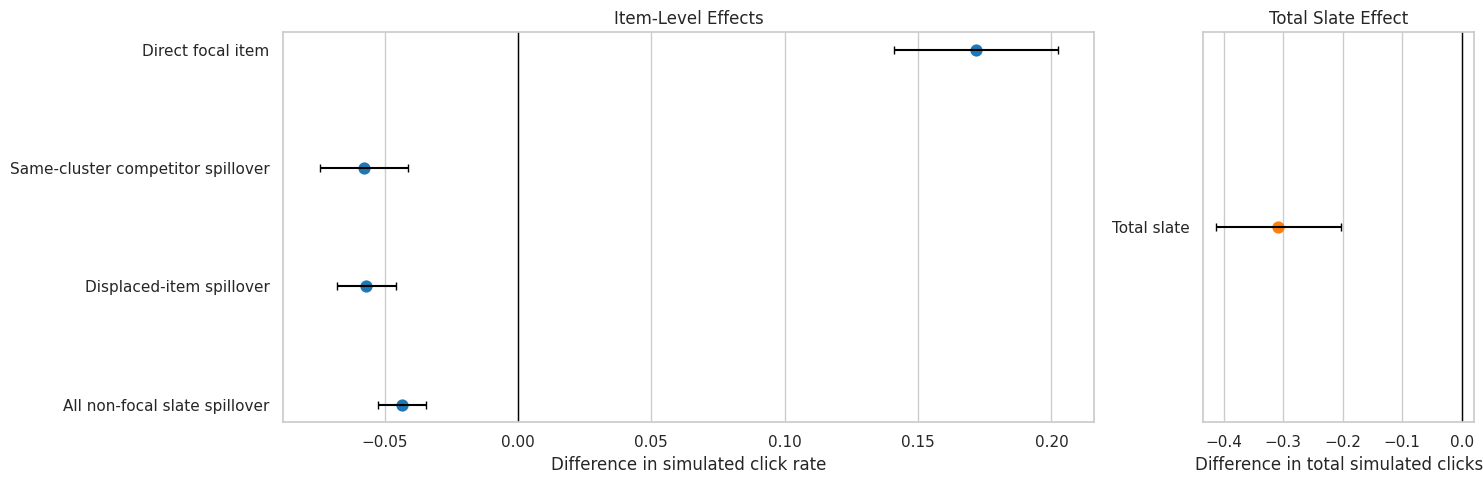

In [8]:
# Plot observed estimates with cluster-Robust intervals.
item_observed = observed_estimates.query("contrast != 'Total slate'").copy()
slate_observed = observed_estimates.query("contrast == 'Total slate'").copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [3, 1]})

sns.pointplot(
    data=item_observed,
    x="estimate",
    y="contrast",
    join=False,
    errorbar=None,
    ax=axes[0],
    color="tab:blue",
)
for y_pos, (_, row) in enumerate(item_observed.reset_index(drop=True).iterrows()):
    axes[0].errorbar(
        x=row["estimate"],
        y=y_pos,
        xerr=[[row["estimate"] - row["ci_95_lower"]], [row["ci_95_upper"] - row["estimate"]]],
        fmt="none",
        color="black",
        capsize=3,
    )
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Item-Level Effects")
axes[0].set_xlabel("Difference in simulated click rate")
axes[0].set_ylabel("")

sns.pointplot(
    data=slate_observed,
    x="estimate",
    y="contrast",
    join=False,
    errorbar=None,
    ax=axes[1],
    color="tab:orange",
)
for y_pos, (_, row) in enumerate(slate_observed.reset_index(drop=True).iterrows()):
    axes[1].errorbar(
        x=row["estimate"],
        y=y_pos,
        xerr=[[row["estimate"] - row["ci_95_lower"]], [row["ci_95_upper"] - row["estimate"]]],
        fmt="none",
        color="black",
        capsize=3,
    )
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Total Slate Effect")
axes[1].set_xlabel("Difference in total simulated clicks")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


The plot makes the direct-versus-spillover tradeoff visible. A promotion can increase the focal item's click chance while decreasing competitor outcomes. The total slate estimate is the product-level summary because it combines both sides of that tradeoff.


### Compare Estimates to Known Simulation Truth

Because this is a simulation, we have two extra validation signals:

- the expected probability estimate, which removes random click noise;
- the known induced lift estimate, which isolates the lift created by the treatment and spillover mechanism.

This cell reshapes the results so each contrast can compare noisy observed estimates against the known simulation signal.


In [9]:
# Compare observed estimates to known simulation truth.
validation_table = estimate_table.pivot_table(
    index="contrast",
    columns="outcome",
    values="estimate",
    aggfunc="first",
).reset_index()

validation_table = validation_table.rename(
    columns={
        "Observed simulated click": "observed_item_click_diff",
        "Expected click probability": "expected_item_probability_diff",
        "Known induced probability lift": "known_item_probability_lift_diff",
        "Observed total simulated clicks": "observed_total_click_diff",
        "Expected total clicks": "expected_total_click_diff",
        "Known total probability lift": "known_total_probability_lift_diff",
    }
)

validation_table["observed_minus_expected"] = np.where(
    validation_table["contrast"].eq("Total slate"),
    validation_table.get("observed_total_click_diff") - validation_table.get("expected_total_click_diff"),
    validation_table.get("observed_item_click_diff") - validation_table.get("expected_item_probability_diff"),
)

validation_table["expected_minus_known_lift"] = np.where(
    validation_table["contrast"].eq("Total slate"),
    validation_table.get("expected_total_click_diff") - validation_table.get("known_total_probability_lift_diff"),
    validation_table.get("expected_item_probability_diff") - validation_table.get("known_item_probability_lift_diff"),
)
validation_table["contrast_order"] = validation_table["contrast"].map(contrast_order)
validation_table = validation_table.sort_values("contrast_order")

display(validation_table)


outcome,contrast,expected_item_probability_diff,expected_total_click_diff,known_item_probability_lift_diff,known_total_probability_lift_diff,observed_item_click_diff,observed_total_click_diff,observed_minus_expected,expected_minus_known_lift,contrast_order
1,Direct focal item,0.1777,NaN,0.1794,NaN,0.1716,NaN,-0.0061,-0.0017,0
3,Same-cluster competitor spillover,-0.0695,NaN,-0.0686,NaN,-0.0577,NaN,0.0118,-0.0009,1
2,Displaced-item spillover,-0.0574,NaN,-0.0580,NaN,-0.0568,NaN,0.0006,0.0007,2
0,All non-focal slate spillover,-0.0450,NaN,-0.0452,NaN,-0.0436,NaN,0.0014,0.0003,3
4,Total slate,NaN,-0.3168,NaN,-0.3180,NaN,-0.3078,0.0090,0.0012,4


The validation table separates random outcome noise from the designed effect. The observed estimate can deviate from the expected estimate because clicks are simulated as Bernoulli outcomes. The expected estimate can differ from known induced lift when treated and control rows have small baseline differences despite randomization.


#### 10. Plot Estimated Effects Versus Known Lift

This plot compares observed, expected, and known-lift estimates for each contrast. It is a useful simulation diagnostic: the observed estimates should be directionally consistent with the expected and known-lift signals, even if sampling noise creates some differences.


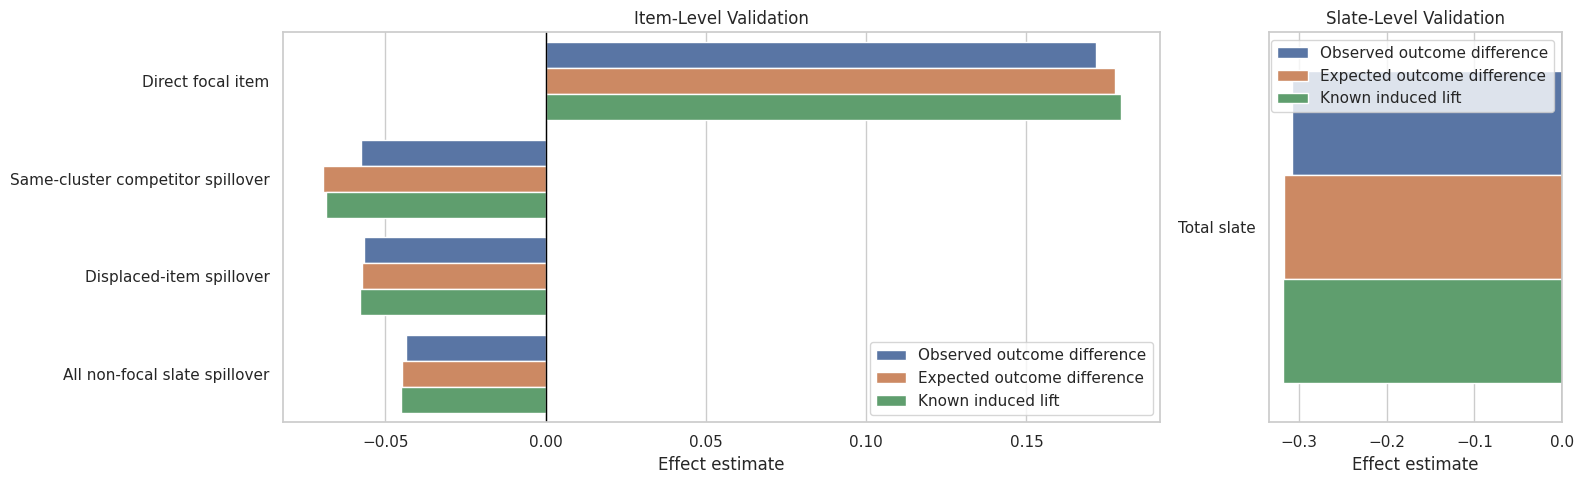

In [10]:
# Plot estimated effects versus known lift.
validation_plot_rows = []
for _, row in validation_table.iterrows():
    if row["contrast"] == "Total slate":
        metrics = {
            "Observed outcome difference": row.get("observed_total_click_diff"),
            "Expected outcome difference": row.get("expected_total_click_diff"),
            "Known induced lift": row.get("known_total_probability_lift_diff"),
        }
    else:
        metrics = {
            "Observed outcome difference": row.get("observed_item_click_diff"),
            "Expected outcome difference": row.get("expected_item_probability_diff"),
            "Known induced lift": row.get("known_item_probability_lift_diff"),
        }
    for metric, value in metrics.items():
        validation_plot_rows.append({"contrast": row["contrast"], "metric": metric, "estimate": value})
validation_plot_df = pd.DataFrame(validation_plot_rows).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [3, 1]})

sns.barplot(
    data=validation_plot_df.query("contrast != 'Total slate'"),
    y="contrast",
    x="estimate",
    hue="metric",
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Item-Level Validation")
axes[0].set_xlabel("Effect estimate")
axes[0].set_ylabel("")
axes[0].legend(title="")

sns.barplot(
    data=validation_plot_df.query("contrast == 'Total slate'"),
    y="contrast",
    x="estimate",
    hue="metric",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Slate-Level Validation")
axes[1].set_xlabel("Effect estimate")
axes[1].set_ylabel("")
axes[1].legend(title="")

plt.tight_layout()
plt.show()


The validation view is the honest bridge between simulation and estimation. It tells us whether the estimator recovers the direction and approximate magnitude of the mechanism we built into the data. Later notebooks can use this as a baseline before moving into formal direct/indirect decomposition.


### Naive versus Clustered Standard Errors

A common mistake in interference settings is to treat item rows as independent even though treatment is assigned to a whole slate. This cell compares naive and cluster-robust standard errors for the observed-outcome estimates.


In [11]:
se_comparison = observed_estimates[
    [
        "contrast",
        "outcome",
        "estimate",
        "naive_se",
        "cluster_se",
        "cluster_to_naive_se_ratio",
        "clusters",
    ]
].copy()
se_comparison["cluster_minus_naive_se"] = se_comparison["cluster_se"] - se_comparison["naive_se"]
se_comparison = se_comparison.sort_values("cluster_to_naive_se_ratio", ascending=False)

display(se_comparison)


,contrast,outcome,estimate,naive_se,cluster_se,cluster_to_naive_se_ratio,clusters,cluster_minus_naive_se
9,All non-focal slate spillover,Observed simulated click,-0.0436,0.0043,0.0046,1.0635,3000,0.0003
6,Displaced-item spillover,Observed simulated click,-0.0568,0.0054,0.0057,1.0419,3000,0.0002
3,Same-cluster competitor spillover,Observed simulated click,-0.0577,0.0083,0.0084,1.0107,2456,0.0001
12,Total slate,Observed total simulated clicks,-0.3078,0.0538,0.0538,1.0001,3000,0.0000
0,Direct focal item,Observed simulated click,0.1716,0.0157,0.0157,0.9992,3000,-0.0000


If the cluster standard error is meaningfully different from the naive standard error, that warns against row-level uncertainty for this design. Even when the estimates are simple, the uncertainty calculation should match the randomized design.


### Cluster Bootstrap for Main Observed Effects

The cluster-robust regression standard errors are analytic. This cell adds a cluster bootstrap, resampling slates with replacement and recomputing the treated-control mean difference. The bootstrap is slower but useful as a second uncertainty check.


In [12]:
# Cluster bootstrap for main observed effects.
BOOTSTRAP_REPS = 500
BOOTSTRAP_SEED = 20260428

bootstrap_jobs = [
    ("Direct focal item", focal_rows, "simulated_click"),
    ("Same-cluster competitor spillover", same_cluster_candidates, "simulated_click"),
    ("Displaced-item spillover", would_be_displaced_candidates, "simulated_click"),
    ("All non-focal slate spillover", non_focal_rows, "simulated_click"),
    ("Total slate", slate_outcomes, "total_simulated_clicks"),
]

bootstrap_rows = []
bootstrap_summaries = []
for i, (contrast, df, outcome) in enumerate(bootstrap_jobs):
    estimates = cluster_bootstrap_difference(
        df,
        outcome=outcome,
        treatment="promotion_applied",
        cluster_col="slate_id",
        n_bootstrap=BOOTSTRAP_REPS,
        seed=BOOTSTRAP_SEED + i,
    )
    estimates = estimates[~np.isnan(estimates)]
    for draw_id, estimate in enumerate(estimates):
        bootstrap_rows.append(
            {
                "contrast": contrast,
                "outcome": outcome,
                "bootstrap_draw": draw_id,
                "estimate": estimate,
            }
        )
    bootstrap_summaries.append(
        {
            "contrast": contrast,
            "outcome": outcome,
            "bootstrap_draws": len(estimates),
            "bootstrap_mean": estimates.mean(),
            "bootstrap_se": estimates.std(ddof=1),
            "bootstrap_ci_95_lower": np.quantile(estimates, 0.025),
            "bootstrap_ci_95_upper": np.quantile(estimates, 0.975),
        }
    )

bootstrap_distribution = pd.DataFrame(bootstrap_rows)
bootstrap_summary = pd.DataFrame(bootstrap_summaries)

display(bootstrap_summary)


,contrast,outcome,bootstrap_draws,bootstrap_mean,bootstrap_se,bootstrap_ci_95_lower,bootstrap_ci_95_upper
0,Direct focal item,simulated_click,500,0.1712,0.0161,0.1383,0.2015
1,Same-cluster competitor spillover,simulated_click,500,-0.0578,0.0083,-0.0733,-0.0420
2,Displaced-item spillover,simulated_click,500,-0.0565,0.0061,-0.0686,-0.0449
3,All non-focal slate spillover,simulated_click,500,-0.0438,0.0047,-0.0524,-0.0343
4,Total slate,total_simulated_clicks,500,-0.3055,0.0536,-0.4169,-0.2042


The bootstrap intervals should usually tell the same qualitative story as the cluster-robust intervals. If they disagree sharply, that would be a sign to inspect skew, leverage, or sparse treated/control support within a contrast.


#### 13. Plot Bootstrap Distributions

This plot shows the cluster bootstrap distribution for each observed effect. The vertical line marks zero, making it easy to see whether the bootstrap mass is mostly positive, mostly negative, or centered near no effect.


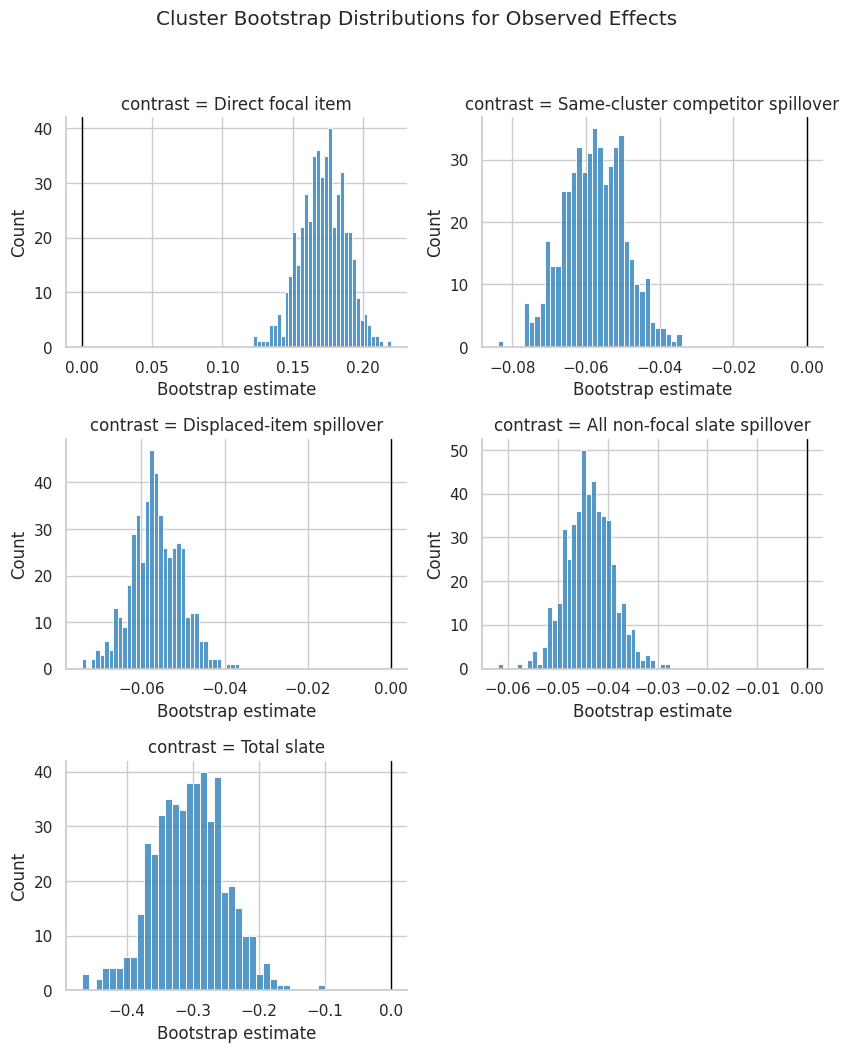

In [13]:
g = sns.FacetGrid(
    bootstrap_distribution,
    col="contrast",
    col_wrap=2,
    sharex=False,
    sharey=False,
    height=3.4,
    aspect=1.25,
)
g.map_dataframe(sns.histplot, x="estimate", bins=35, color="tab:blue")
for ax in g.axes.flat:
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Bootstrap estimate")
g.fig.suptitle("Cluster Bootstrap Distributions for Observed Effects", y=1.03)
plt.tight_layout()
plt.show()


The bootstrap plots add shape information that a table cannot show. For example, slate-level total effects can have a wider distribution because total clicks aggregate many item outcomes and because displacement varies by focal position and cluster composition.


### Decompose the Total Slate Effect

The total slate effect combines focal gains and competitor losses. This cell uses the known expected lift components from the simulation to decompose promoted slates into direct focal lift, same-cluster spillover loss, other-spillover loss, and net total lift.

This diagnostic shows why the total effect can differ from the direct effect. It is a diagnostic showing why the total effect can differ from the direct effect.


In [14]:
promoted_slates = slate_outcomes.query("promotion_applied == 1").copy()

direct_component = promoted_slates["direct_expected_lift"].mean()
slate_decomposition = pd.DataFrame(
    {
        "component": [
            "Direct focal expected lift",
            "Same-cluster spillover expected lift",
            "Other spillover expected lift",
            "Net total expected lift",
        ],
        "mean_lift_per_promoted_slate": [
            direct_component,
            promoted_slates["same_cluster_spillover_expected_lift"].mean(),
            promoted_slates["other_spillover_expected_lift"].mean(),
            promoted_slates["total_known_probability_lift"].mean(),
        ],
    }
)
slate_decomposition["share_of_direct_gain_magnitude"] = (
    slate_decomposition["mean_lift_per_promoted_slate"] / abs(direct_component)
)

display(slate_decomposition)


,component,mean_lift_per_promoted_slate,share_of_direct_gain_magnitude
0,Direct focal expected lift,0.1794,1.0000
1,Same-cluster spillover expected lift,-0.1965,-1.0953
2,Other spillover expected lift,-0.3010,-1.6777
3,Net total expected lift,-0.3180,-1.7730


The decomposition is the core product lesson of this interference project. Looking only at the promoted item can make an intervention look good, while the net slate effect can be weaker or negative once substitute and displaced-item losses are counted.


#### 15. Plot the Total Effect Decomposition

This plot turns the decomposition into a report-friendly figure. Positive bars represent focal gains, while negative bars represent spillover losses. The net bar summarizes the slate-level consequence.


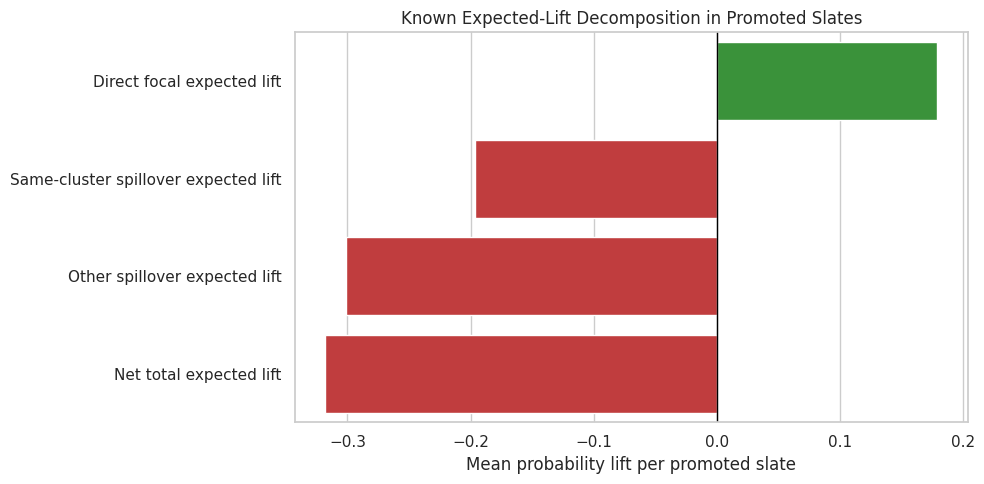

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["tab:green" if value >= 0 else "tab:red" for value in slate_decomposition["mean_lift_per_promoted_slate"]]
sns.barplot(
    data=slate_decomposition,
    x="mean_lift_per_promoted_slate",
    y="component",
    hue="component",
    palette=dict(zip(slate_decomposition["component"], colors)),
    legend=False,
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Known Expected-Lift Decomposition in Promoted Slates")
ax.set_xlabel("Mean probability lift per promoted slate")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


This figure explains why interference changes the evaluation question. The promoted item is only one part of the slate. A good recommender evaluation should ask whether the whole slate, cluster, or user session improved after accounting for displaced attention.


### Cluster-Level Effect Heterogeneity

Spillovers may differ by genre cluster. This cell estimates observed direct focal effects and same-cluster spillover effects for clusters with enough support. These estimates are exploratory; the goal is to see where the simulated mechanism is strongest and where data are too sparse.


In [16]:
# cluster-level effect heterogeneity.
MIN_CLUSTER_ARM_ROWS = 30
cluster_effect_rows = []

for cluster, df in focal_rows.groupby("focal_spillover_cluster"):
    treated_n = int(df["promotion_applied"].sum())
    control_n = int((1 - df["promotion_applied"]).sum())
    if treated_n >= MIN_CLUSTER_ARM_ROWS and control_n >= MIN_CLUSTER_ARM_ROWS:
        result = difference_in_means(
            df,
            outcome="simulated_click",
            treatment="promotion_applied",
            cluster_col="slate_id",
            contrast_name="Direct focal item",
            outcome_label="Observed simulated click",
        )
        result["cluster"] = cluster
        result["effect_family"] = "direct"
        cluster_effect_rows.append(result)

for cluster, df in same_cluster_candidates.groupby("focal_spillover_cluster"):
    treated_n = int(df["promotion_applied"].sum())
    control_n = int((1 - df["promotion_applied"]).sum())
    if treated_n >= MIN_CLUSTER_ARM_ROWS and control_n >= MIN_CLUSTER_ARM_ROWS:
        result = difference_in_means(
            df,
            outcome="simulated_click",
            treatment="promotion_applied",
            cluster_col="slate_id",
            contrast_name="Same-cluster competitor spillover",
            outcome_label="Observed simulated click",
        )
        result["cluster"] = cluster
        result["effect_family"] = "same_cluster_spillover"
        cluster_effect_rows.append(result)

cluster_effects = pd.DataFrame(cluster_effect_rows)
cluster_effects = cluster_effects.sort_values(["effect_family", "estimate"])

display(cluster_effects[
    [
        "effect_family",
        "cluster",
        "estimate",
        "cluster_se",
        "ci_95_lower",
        "ci_95_upper",
        "treated_n",
        "control_n",
        "clusters",
    ]
])


,effect_family,cluster,estimate,cluster_se,ci_95_lower,ci_95_upper,treated_n,control_n,clusters
6,direct,Horror,0.0787,0.0981,-0.1135,0.2710,31,34,65
5,direct,Drama,0.1179,0.0339,0.0514,0.1844,317,319,636
0,direct,Action,0.1659,0.0298,0.1074,0.2243,401,398,799
4,direct,Crime,0.1660,0.0560,0.0563,0.2757,130,123,253
3,direct,Comedy,0.1924,0.0334,0.1269,0.2578,338,320,658
1,direct,Adventure,0.2329,0.0483,0.1382,0.3275,168,150,318
2,direct,Animation,0.3372,0.1054,0.1306,0.5437,32,38,70
9,same_cluster_spillover,Animation,-0.1957,0.0852,-0.3627,-0.0288,32,38,35
8,same_cluster_spillover,Adventure,-0.0847,0.0350,-0.1532,-0.0162,282,226,219
12,same_cluster_spillover,Drama,-0.0753,0.0179,-0.1105,-0.0402,974,1012,587


The cluster-level table is exploratory and helps identify where direct gains or spillover losses may be concentrated. It helps identify where direct gains or spillover losses may be concentrated. Sparse clusters are filtered out so the table stays focused on segments with enough treated and control support.


#### 17. Plot Cluster-Level Direct and Spillover Effects

This plot shows the exploratory cluster effects with intervals. It is useful for seeing whether some content groups are more displacement-prone than others.


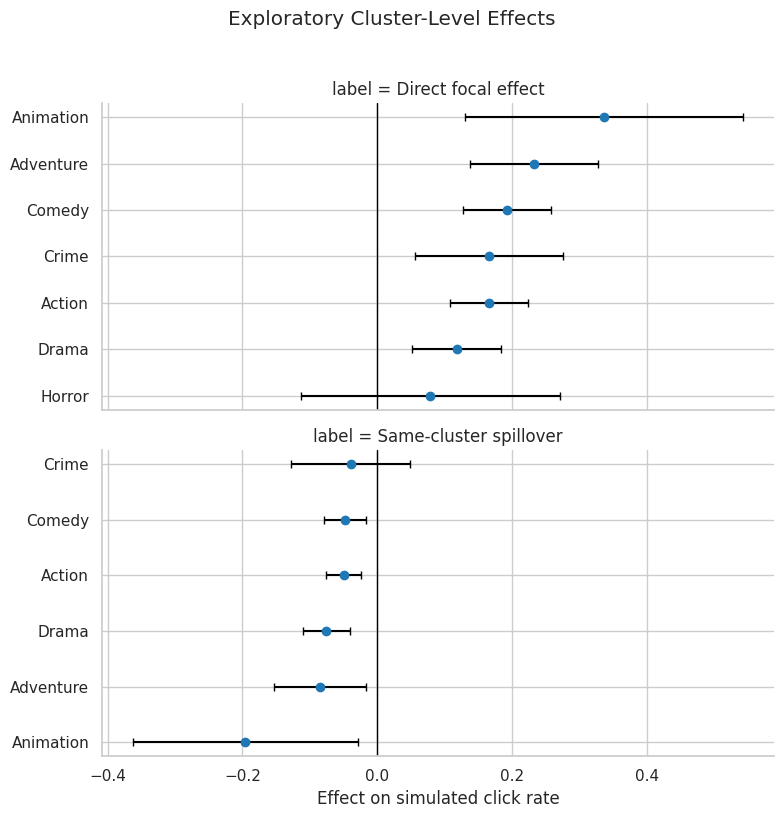

In [17]:
# Plot cluster-Level direct and spillover effects.
if not cluster_effects.empty:
    plot_cluster_effects = cluster_effects.copy()
    plot_cluster_effects["label"] = plot_cluster_effects["effect_family"].map(
        {
            "direct": "Direct focal effect",
            "same_cluster_spillover": "Same-cluster spillover",
        }
    )

    g = sns.FacetGrid(
        plot_cluster_effects,
        row="label",
        sharex=True,
        sharey=False,
        height=4.0,
        aspect=2.0,
    )

    def point_ci(data, **kwargs):
        """
        Summarize a vector of bootstrap estimates with a point and interval.
        
        Idea
        ----
        This helper turns bootstrap draws into the estimate and confidence limits displayed in validation plots.
        
        Parameters
        ----------
        data : object
            Input analysis table for the current project step.
        
        Returns
        -------
        pandas.Series
            Point estimate and confidence interval bounds.
        """
        ax = plt.gca()
        ordered = data.sort_values("estimate")
        y_positions = np.arange(len(ordered))
        ax.errorbar(
            x=ordered["estimate"],
            y=y_positions,
            xerr=[
                ordered["estimate"] - ordered["ci_95_lower"],
                ordered["ci_95_upper"] - ordered["estimate"],
            ],
            fmt="o",
            color="tab:blue",
            ecolor="black",
            capsize=3,
        )
        ax.set_yticks(y_positions)
        ax.set_yticklabels(ordered["cluster"])
        ax.axvline(0, color="black", linewidth=1)
        ax.set_xlabel("Effect on simulated click rate")
        ax.set_ylabel("")

    g.map_dataframe(point_ci)
    g.fig.suptitle("Exploratory Cluster-Level Effects", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No clusters met the minimum support threshold.")


The cluster plot should be read as a guide for deeper analysis. Later notebooks can formalize these ideas by decomposing effects and checking sensitivity to the spillover exposure definition.


In [ ]:
#| include: false
# Save estimation artifacts.
ESTIMATE_OUTPUT = PROCESSED_DIR / "movielens_interference_cluster_estimates.csv"
OBSERVED_OUTPUT = PROCESSED_DIR / "movielens_interference_observed_effects.csv"
VALIDATION_OUTPUT = PROCESSED_DIR / "movielens_interference_estimator_validation.csv"
BOOTSTRAP_OUTPUT = PROCESSED_DIR / "movielens_interference_cluster_bootstrap.csv"
BOOTSTRAP_SUMMARY_OUTPUT = PROCESSED_DIR / "movielens_interference_cluster_bootstrap_summary.csv"
DECOMPOSITION_OUTPUT = PROCESSED_DIR / "movielens_interference_slate_decomposition.csv"
CLUSTER_EFFECT_OUTPUT = PROCESSED_DIR / "movielens_interference_cluster_effects.csv"

estimate_table.to_csv(ESTIMATE_OUTPUT, index=False)
observed_estimates.to_csv(OBSERVED_OUTPUT, index=False)
validation_table.to_csv(VALIDATION_OUTPUT, index=False)
bootstrap_distribution.to_csv(BOOTSTRAP_OUTPUT, index=False)
bootstrap_summary.to_csv(BOOTSTRAP_SUMMARY_OUTPUT, index=False)
slate_decomposition.to_csv(DECOMPOSITION_OUTPUT, index=False)
cluster_effects.to_csv(CLUSTER_EFFECT_OUTPUT, index=False)


The saved files are the handoff to the next notebook. The most important tables are the observed effects, the validation table, and the slate decomposition. Together they show the estimated promoted-item gain, the estimated spillover loss, and the net slate consequence.


### Takeaways and Next Step

This notebook estimated the randomized promotion simulation from several angles:

- The direct focal-item effect measures the gain from moving a lower-ranked movie to the top of a slate.
- Same-cluster and displaced-item contrasts measure competitor losses caused by the same promotion.
- The total slate effect measures the net product outcome after combining focal gains and spillover losses.
- Clustered uncertainty is the right default because promotion is assigned at the slate level.
- The known simulation signal confirms why interference matters: a direct gain can coexist with a weaker or negative total slate effect.

The next notebook should formalize the decomposition into direct, indirect, and total effects, then compare alternative exposure definitions such as same-slate spillover, same-cluster spillover, and displaced-position spillover.
